In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('./data/annotated_filtered_col.CG_2.fast.tsv', sep='\t')      # or read_parquet / feather …
df

,cluster,chr,start,end,score,c,t,n,flag_euc_gene,flag_het_gene,flag_euc_TE,flag_het_TE,score_masked
0,0,1,101,200,0.8951,350,41,6,False,False,False,False,0.8951
1,0,1,301,400,0.5487,62,51,2,False,False,False,False,0.5487
2,0,1,401,500,0.8246,47,10,1,False,False,False,False,0.8246
3,0,1,501,600,0.7206,98,38,3,False,False,False,False,0.7206
4,0,1,601,700,0.8982,203,23,6,False,False,False,False,0.8982
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5925984,16,5,26974801,26974900,0.8462,22,4,7,False,False,False,False,0.8462
5925985,16,5,26974901,26975000,0.7500,3,1,2,False,False,False,False,NaN
5925986,16,5,26975101,26975200,1.0000,4,0,4,False,False,False,False,NaN
5925987,16,5,26975201,26975300,1.0000,8,0,8,False,False,False,False,1.0000


In [4]:
regions = pd.read_pickle("./data/sig_region.pkl")
regions

,chr,start,end,length_bp,n_windows,min_qval,max_delta,mean_delta
0,1,76801,77300,500,3,0.000000e+00,0.587940,0.556828
1,1,116901,117300,400,3,0.000000e+00,0.537025,0.479695
2,1,281801,282200,400,3,1.226815e-03,0.270856,0.247911
3,1,282601,282800,200,2,4.359180e-08,0.400563,0.383799
4,1,292201,292600,400,4,2.828629e-07,0.447647,0.338340
...,...,...,...,...,...,...,...,...
2716,5,26866401,26867200,800,5,0.000000e+00,0.524355,0.443220
2717,5,26885001,26885700,700,6,0.000000e+00,0.657076,0.574918
2718,5,26885901,26886400,500,5,0.000000e+00,0.517858,0.423792
2719,5,26886601,26886900,300,2,3.711941e-03,0.419719,0.360778


In [46]:
df[df['start']>76800]

,cluster,chr,start,end,score,c,t,n,flag_euc_gene,flag_het_gene,flag_euc_TE,flag_het_TE,score_masked
121,0,1,76801,76900,0.7797,138,39,4,True,False,True,False,0.7797
122,0,1,76901,77000,0.9121,83,8,2,False,False,True,False,0.9121
123,0,1,77001,77100,0.8858,411,53,8,False,False,True,False,0.8858
124,0,1,77201,77300,0.9338,381,27,8,False,False,True,False,0.9338
125,0,1,77301,77400,0.9544,251,12,10,False,False,True,False,0.9544
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5925984,16,5,26974801,26974900,0.8462,22,4,7,False,False,False,False,0.8462
5925985,16,5,26974901,26975000,0.7500,3,1,2,False,False,False,False,NaN
5925986,16,5,26975101,26975200,1.0000,4,0,4,False,False,False,False,NaN
5925987,16,5,26975201,26975300,1.0000,8,0,8,False,False,False,False,1.0000


In [50]:
import numpy as np
import pandas as pd
import pyranges as pr

# --- 1) Collapse per-cluster rows -> unique genomic windows (OR flags per window) ---
def unique_windows_from_df(df,
                           flag_cols=('flag_euc_gene','flag_het_gene','flag_euc_TE','flag_het_TE')):
    """
    df: original per-100bp window table with multiple rows per window (one per cluster).
        Must include ['chr','start','end'] and the flag columns.
    Returns one row per unique (chr,start,end) with flags OR'ed across clusters, plus 'uncategorized'.
    """
    uw = (df.groupby(['chr','start','end'], as_index=False)
            .agg(**{f:(f,'any') for f in flag_cols}))
    uw['uncategorized'] = ~uw[list(flag_cols)].any(axis=1)
    return uw

# --- 2) Robust suffix detection for PyRanges.join outputs ---
def _detect_window_cols(ov_df):
    """
    Given a DataFrame from PyRanges.join(...).df, return the column names
    for the window side (Chromosome, Start, End) regardless of suffix.
    """
    candidates = [
        ('Chromosome_win','Start_win','End_win'),  # if suffix="_win"
        ('Chromosome_b','Start_b','End_b'),        # default suffix
        ('Chromosome','Start','End')               # no suffix (e.g., disjoint names)
    ]
    for cols in candidates:
        if all(c in ov_df.columns for c in cols):
            return list(cols)
    # If nothing matches, raise a helpful error
    raise KeyError(
        "Could not find window coordinate columns in join result. "
        "Expected one of: (_win), (_b), or no suffix."
    )

# --- 3) Count raw window occurrences per flag inside each chunk ---
def count_flags_per_chunk(chunks, df_full,
                          flag_cols=('flag_euc_gene','flag_het_gene','flag_euc_TE','flag_het_TE'),
                          add_uncategorized=True,
                          join_suffix="_win"):
    """
    chunks: DataFrame with 1-based inclusive ['chr','start','end'] (plus any other cols).
    df_full: original per-100bp table (multi-cluster). Must include ['chr','start','end'] and flags.
    flag_cols: the four boolean flags to count independently.
    add_uncategorized: if True, also count windows that have no flags True.
    join_suffix: suffix to request from PyRanges.join (e.g., "_win"); detection is robust regardless.

    Returns: chunks with added integer columns:
        count_flag_euc_gene, count_flag_het_gene, count_flag_euc_TE, count_flag_het_TE,
        [count_uncategorized], n_unique_windows
    """
    # 1) collapse to unique windows with OR'ed flags
    windows_unique = unique_windows_from_df(df_full, flag_cols=flag_cols)

    # 2) build PyRanges (convert 1-based inclusive -> 0-based, end-exclusive)
    ch = chunks.copy()
    ch = ch.assign(Chromosome=ch['chr'].astype(str),
                   Start=ch['start'] - 1,
                   End=ch['end'])
    ch['chunk_id'] = np.arange(len(ch))
    gr_chunks = pr.PyRanges(ch[['Chromosome','Start','End','chunk_id']])

    wu = windows_unique.copy()
    wu = wu.assign(Chromosome=wu['chr'].astype(str),
                   Start=wu['start'] - 1,
                   End=wu['end'])
    cols_win = ['Chromosome','Start','End'] + list(flag_cols)
    if add_uncategorized:
        cols_win += ['uncategorized']
    gr_win = pr.PyRanges(wu[cols_win])

    # 3) join; allow the caller to choose suffix, but handle any outcome
    ov = gr_chunks.join(gr_win, suffix=join_suffix).df

    # 4) dedup one count per unique window × chunk
    win_cols = _detect_window_cols(ov)                           # e.g., ['Chromosome_win','Start_win','End_win']
    ov = ov.drop_duplicates(subset=['chunk_id'] + win_cols)

    # 5) sum True flags per chunk (True->1, False->0)
    sum_cols = list(flag_cols) + (['uncategorized'] if add_uncategorized else [])
    # Ensure these columns exist (in case some flags were entirely absent post-join)
    for c in sum_cols:
        if c not in ov.columns:
            ov[c] = 0

    counts = (ov.groupby('chunk_id')[sum_cols]
                .sum()
                .astype(int)
                .reset_index())

    # also count total unique windows overlapped (sanity)
    tot = (ov.groupby('chunk_id')
             .size()
             .rename('n_unique_windows')
             .reset_index())

    # 6) stitch back
    out = chunks.copy().reset_index(drop=True)
    out = out.join(counts.set_index('chunk_id'), how='left')
    out = out.join(tot.set_index('chunk_id'), how='left')

    # fill zeros for chunks with no overlaps
    fill_cols = [f'count_{c}' for c in sum_cols]  # final names we want
    # rename summed flags -> count_flag_*
    rename_map = {c: f'count_{c}' for c in sum_cols}
    out.rename(columns=rename_map, inplace=True)

    for c in fill_cols + ['n_unique_windows']:
        if c not in out.columns:
            out[c] = 0
        out[c] = out[c].fillna(0).astype(int)

    return out


In [52]:
# Example:
chunks_counts = count_flags_per_chunk(chunks, df, join_suffix="_win")
chunks_counts
# Now chunks_counts has:
#   count_flag_euc_gene, count_flag_het_gene, count_flag_euc_TE, count_flag_het_TE,
#   count_uncategorized (if add_uncategorized=True),
#   n_unique_windows


,chr,start,end,length_bp,n_windows,min_qval,max_delta,mean_delta,count_flag_euc_gene,count_flag_het_gene,count_flag_euc_TE,count_flag_het_TE,count_uncategorized,n_unique_windows
0,1,76801,77300,500,3,0.000000e+00,0.587940,0.556828,1,0,1,0,0,1
1,1,116901,117300,400,3,0.000000e+00,0.537025,0.479695,1,0,0,0,0,1
2,1,281801,282200,400,3,1.226815e-03,0.270856,0.247911,1,0,0,0,0,1
3,1,282601,282800,200,2,4.359180e-08,0.400563,0.383799,1,0,0,0,0,1
4,1,292201,292600,400,4,2.828629e-07,0.447647,0.338340,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2716,5,26866401,26867200,800,5,0.000000e+00,0.524355,0.443220,1,0,0,0,0,1
2717,5,26885001,26885700,700,6,0.000000e+00,0.657076,0.574918,1,0,0,0,0,1
2718,5,26885901,26886400,500,5,0.000000e+00,0.517858,0.423792,1,0,0,0,0,1
2719,5,26886601,26886900,300,2,3.711941e-03,0.419719,0.360778,1,0,0,0,0,1


In [ ]:
overlap

In [35]:
import numpy as np
import pandas as pd
import pyranges as pr

# 1) tag each window with a single category (or 'unannotated' if none)
def assign_window_category(df):
    prio = ['flag_euc_gene','flag_het_gene','flag_euc_TE','flag_het_TE']
    catmap = {
        'flag_euc_gene':'euc_gene',
        'flag_het_gene':'het_gene',
        'flag_euc_TE':'euc_te',
        'flag_het_TE':'het_te'
    }
    def pick(row):
        for f in prio:
            if f in row and bool(row[f]):  # first True wins
                return catmap[f]
        return 'unannotated'
    out = df.copy()
    out['win_category'] = out.apply(pick, axis=1)
    return out

# 2) annotate chunks with RAW COUNTS per category (no fractions)
def annotate_chunks_with_counts_pyranges(chunks, windows):
    """
    chunks: DataFrame with 1-based inclusive ['chr','start','end', ...]
    windows: original per-100bp windows with flags and ['chr','start','end', ...]
    returns: original chunk columns + count_* columns + chunk_category (mode) + total_windows_overlapped
    """
    # per-window category
    win = assign_window_category(windows)

    # convert to 0-based half-open for PyRanges
    ch = chunks.copy()
    ch = ch.assign(
        Chromosome = ch['chr'].astype(str),
        Start = ch['start'] - 1,
        End   = ch['end']
    )[['Chromosome','Start','End']].copy()
    ch['chunk_id'] = np.arange(len(ch))  # stable id

    w = win.copy()
    w = w.assign(
        Chromosome = w['chr'].astype(str),
        Start = w['start'] - 1,
        End   = w['end']
    )[['Chromosome','Start','End','win_category']].copy()

    gr_chunks  = pr.PyRanges(ch)
    gr_windows = pr.PyRanges(w)

    # overlaps between chunks and windows
    ov = gr_chunks.join(gr_windows, suffix="_win").df  # columns include chunk_id, win_category

    # start with original chunks + default counts = 0
    out = chunks.copy().reset_index(drop=True)
    out['total_windows_overlapped'] = 0
    for col in ['euc_gene','het_gene','euc_te','het_te','unannotated']:
        out[f'count_{col}'] = 0
    out['chunk_category'] = 'no_overlap'

    if ov.empty:
        return out

    # raw counts per chunk × category
    counts = (
        ov[['chunk_id','win_category']]
        .groupby(['chunk_id','win_category'])
        .size()
        .reset_index(name='n')
    )

    # pivot to wide counts
    wide = counts.pivot(index='chunk_id', columns='win_category', values='n').fillna(0).astype(int)
    # ensure all expected columns exist
    for col in ['euc_gene','het_gene','euc_te','het_te','unannotated']:
        if col not in wide.columns:
            wide[col] = 0
    wide = wide[['euc_gene','het_gene','euc_te','het_te','unannotated']].reset_index()

    # total overlapped windows per chunk
    wide['total_windows_overlapped'] = wide[['euc_gene','het_gene','euc_te','het_te','unannotated']].sum(axis=1)

    # choose modal category (ties broken by priority)
    priority = {'euc_gene':0, 'het_gene':1, 'euc_te':2, 'het_te':3, 'unannotated':4}
    # find argmax per row with tie-break
    def pick_mode(row):
        # gather (category, count)
        pairs = [(c, row[c]) for c in ['euc_gene','het_gene','euc_te','het_te','unannotated']]
        max_n = max(n for _, n in pairs)
        # among ties, pick lowest priority index
        tied = [c for c, n in pairs if n == max_n]
        return sorted(tied, key=lambda c: priority[c])[0] if max_n > 0 else 'no_overlap'

    wide['chunk_category'] = wide.apply(pick_mode, axis=1)

    # merge back to out
    out = out.join(wide.set_index('chunk_id'), how='left', rsuffix='_new')

    # fill NaNs (chunks with no overlap stay at zeros / no_overlap)
    for col in ['euc_gene','het_gene','euc_te','het_te','unannotated']:
        out[f'count_{col}'] = out[f'{col}'].fillna(0).astype(int)
        out.drop(columns=[col], inplace=True)
    out['total_windows_overlapped'] = out['total_windows_overlapped'].fillna(0).astype(int)
    out['chunk_category'] = out['chunk_category_new'].fillna(out['chunk_category'])
    out.drop(columns=['chunk_category_new'], inplace=True)

    return out


In [37]:
# ---------- Example usage ----------
#chunks_annot = annotate_chunks_with_counts_pyranges(regions, df)
chunks_annot

,chr,start,end,length_bp,n_windows,min_qval,max_delta,mean_delta,total_windows_overlapped,count_euc_gene,count_het_gene,count_euc_te,count_het_te,count_unannotated,chunk_category,total_windows_overlapped_new
0,1,76801,77300,500,3,0.000000e+00,0.587940,0.556828,0,15,0,50,0,0,euc_te,65
1,1,116901,117300,400,3,0.000000e+00,0.537025,0.479695,0,50,0,0,0,0,euc_gene,50
2,1,281801,282200,400,3,1.226815e-03,0.270856,0.247911,0,51,0,0,0,0,euc_gene,51
3,1,282601,282800,200,2,4.359180e-08,0.400563,0.383799,0,34,0,0,0,0,euc_gene,34
4,1,292201,292600,400,4,2.828629e-07,0.447647,0.338340,0,0,0,0,0,68,unannotated,68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2716,5,26866401,26867200,800,5,0.000000e+00,0.524355,0.443220,0,102,0,0,0,0,euc_gene,102
2717,5,26885001,26885700,700,6,0.000000e+00,0.657076,0.574918,0,119,0,0,0,0,euc_gene,119
2718,5,26885901,26886400,500,5,0.000000e+00,0.517858,0.423792,0,85,0,0,0,0,euc_gene,85
2719,5,26886601,26886900,300,2,3.711941e-03,0.419719,0.360778,0,50,0,0,0,0,euc_gene,50


<Axes: >

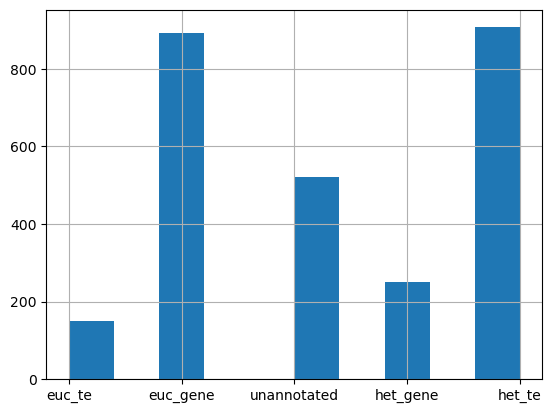

In [15]:
chunks_annot['chunk_category'].hist()

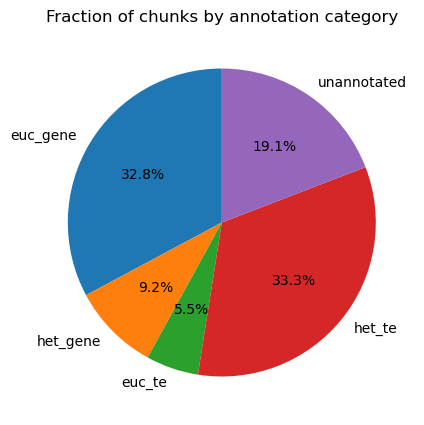

In [25]:
import matplotlib.pyplot as plt

# collapse categories
chunks_annot2 = chunks_annot.copy()
chunks_annot2['chunk_category2'] = chunks_annot2['chunk_category'].replace(
    {"no_overlap":"unannotated"}
)

# count chunks per category
counts = chunks_annot2['chunk_category2'].value_counts()

# sort to desired order (genes/TEs/non)
order = ['euc_gene','het_gene','euc_te','het_te','unannotated']
counts = counts.reindex(order).fillna(0).astype(int)

# pie chart
fig, ax = plt.subplots(figsize=(5,5))
ax.pie(counts, labels=counts.index,
       autopct='%1.1f%%', startangle=90)
ax.set_title("Fraction of chunks by annotation category")
plt.show()


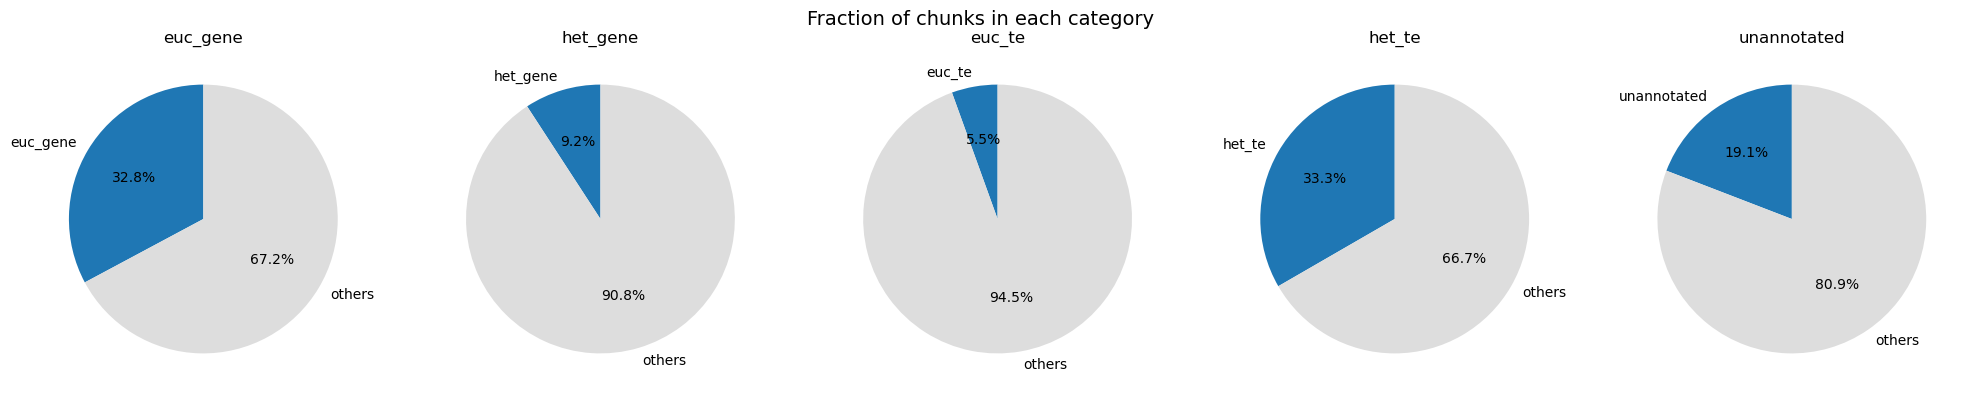

In [26]:
import matplotlib.pyplot as plt

# collapse no_overlap into unannotated
chunks_annot2 = chunks_annot.copy()
chunks_annot2['chunk_category2'] = chunks_annot2['chunk_category'].replace(
    {"no_overlap":"unannotated"}
)

# counts
counts = chunks_annot2['chunk_category2'].value_counts()
order = ['euc_gene','het_gene','euc_te','het_te','unannotated']
counts = counts.reindex(order).fillna(0).astype(int)

total = counts.sum()

# make 5 separate pies
fig, axes = plt.subplots(1, 5, figsize=(20,4))

for ax, cat in zip(axes, order):
    val = counts[cat]
    rest = total - val
    ax.pie([val, rest],
           labels=[cat, "others"],
           autopct='%1.1f%%',
           startangle=90,
           colors=["#1f77b4","#dddddd"])
    ax.set_title(cat)

plt.suptitle("Fraction of chunks in each category", fontsize=14)
plt.tight_layout()
plt.show()


In [27]:
32.8+9.2+5.5+33.3+19.1

99.9

In [16]:
df_all = df.copy()
df_all['is_gene'] = df_all['flag_euc_gene'] | df_all['flag_het_gene']
df_all['is_te']   = df_all['flag_euc_TE']   | df_all['flag_het_TE']

# category label
df_all['category'] = np.where(df_all['is_gene'], 'gene',
                       np.where(df_all['is_te'], 'te', 'other'))


In [20]:
chunks = regions

In [21]:
import pyranges as pr

# original windows as PyRanges
w = df_all.assign(Chromosome=df_all['chr'].astype(str),
                  Start=df_all['start']-1,  # 0-based
                  End=df_all['end'])
gr_win = pr.PyRanges(w[['Chromosome','Start','End','category']])

# chunks as PyRanges
c = chunks.assign(Chromosome=chunks['chr'].astype(str),
                  Start=chunks['start']-1,
                  End=chunks['end'])
gr_chunks = pr.PyRanges(c[['Chromosome','Start','End']])

# intersect
overlap = gr_win.join(gr_chunks).df


In [22]:
# total windows per category
totals = df_all['category'].value_counts()

# overlapping windows per category
captured = overlap['category'].value_counts()

summary = pd.DataFrame({
    "total": totals,
    "captured": captured
}).fillna(0).astype(int)

summary['fraction'] = summary['captured'] / summary['total']
print(summary)


            total  captured  fraction
category                             
gene      2650877     55537  0.020950
te        2444873     51083  0.020894
other      830239     26430  0.031834


In [23]:
# total windows per category
totals = df_all['category'].value_counts()

# overlapping windows per category
captured = overlap['category'].value_counts()

summary = pd.DataFrame({
    "total": totals,
    "captured": captured
}).fillna(0).astype(int)

summary['fraction'] = summary['captured'] / summary['total']
print(summary)


            total  captured  fraction
category                             
gene      2650877     55537  0.020950
te        2444873     51083  0.020894
other      830239     26430  0.031834


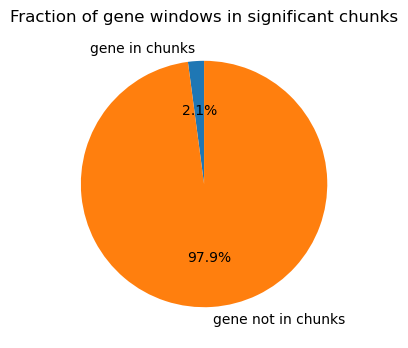

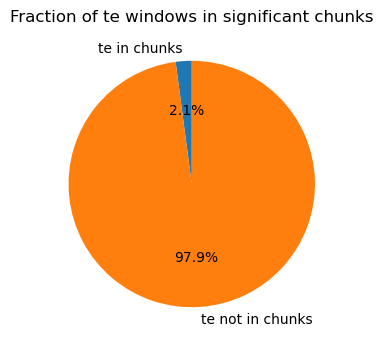

In [24]:
import matplotlib.pyplot as plt

for cat in ['gene','te']:
    total = summary.loc[cat, 'total']
    captured = summary.loc[cat, 'captured']
    not_captured = total - captured
    
    plt.figure(figsize=(4,4))
    plt.pie([captured, not_captured],
            labels=[f"{cat} in chunks", f"{cat} not in chunks"],
            autopct='%1.1f%%',
            startangle=90)
    plt.title(f"Fraction of {cat} windows in significant chunks")
    plt.show()


In [ ]:
#300 chunks. 